In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": True, "mathtext.fontset": "dejavuserif"})

In [2]:
N = 64
bounds1 = pd.read_csv("bounds1.csv")
bounds2true = pd.read_csv("bounds2true.csv")
bounds2approx = pd.read_csv("bounds2approx.csv")
colors = ["#4053d3", "#ddb310", "#b51d14", "#00beff", "#fb49b0", "#00b25d"]
ns = [18, 24, 30, 36, 42, 48]
ks = [18, 24, 30, 36, 42, 48]
title_fs = 24
label_fs = 20

In [3]:
def plot_curves(df, ax, group_col, x_col, y_col, values, labels, left_label=True):
    for c, v in zip(colors, values):
        d = df[df[group_col] == v].sort_values(x_col)
        ax.plot(d[x_col], d[y_col], color=c)
        x, y = (d[x_col].iloc[0], d[y_col].iloc[0]) if left_label else (d[x_col].iloc[-1], d[y_col].iloc[-1])
        ax.text(x, y, f"{labels}={v}", fontsize=14, ha="left" if left_label else "right", va="bottom")
    ax.tick_params(axis="both", labelsize=16)

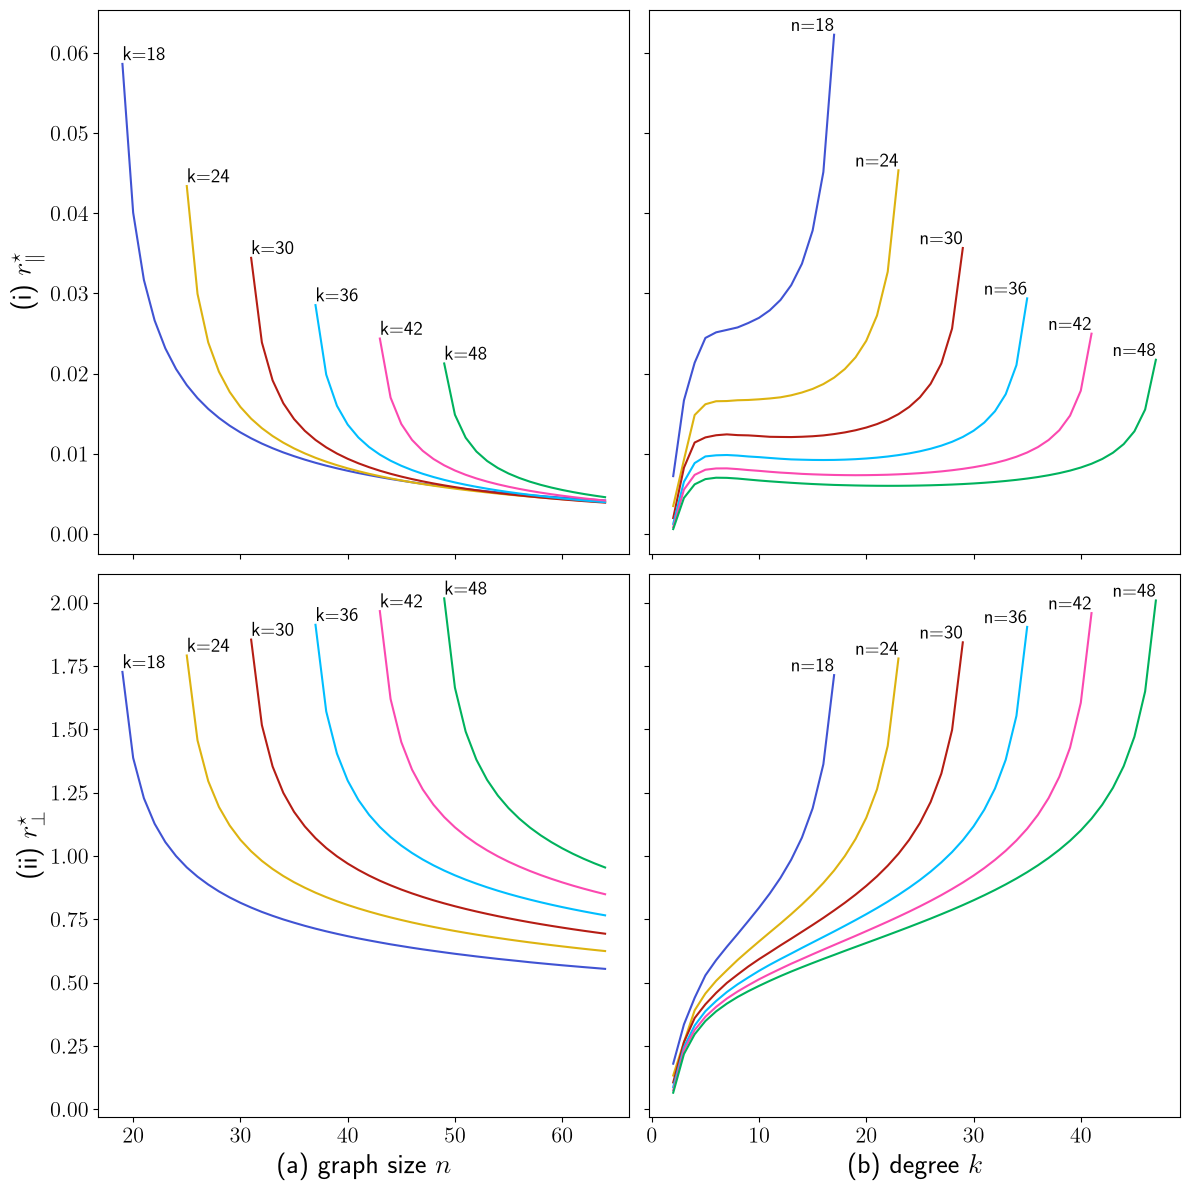

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex="col", sharey="row")

plot_curves(bounds2true, axes[0, 0], "k", "n", "avg_rprmax", ks, "k")
plot_curves(bounds2true, axes[0, 1], "n", "k", "avg_rprmax", ns, "n", left_label=False)
plot_curves(bounds2true, axes[1, 0], "k", "n", "avg_rppmax", ks, "k")
plot_curves(bounds2true, axes[1, 1], "n", "k", "avg_rppmax", ns, "n", left_label=False)

axes[0, 0].set_ylabel(r"(i) $r_\parallel^\star$", fontsize=label_fs)
axes[1, 0].set_ylabel(r"(ii) $r_\perp^\star$", fontsize=label_fs)
axes[1, 0].set_xlabel(r"(a) graph size $n$", fontsize=label_fs)
axes[1, 1].set_xlabel(r"(b) degree $k$", fontsize=label_fs)

plt.tight_layout()
plt.savefig("../images/regular-exact.png", bbox_inches="tight", dpi=400)
plt.show()

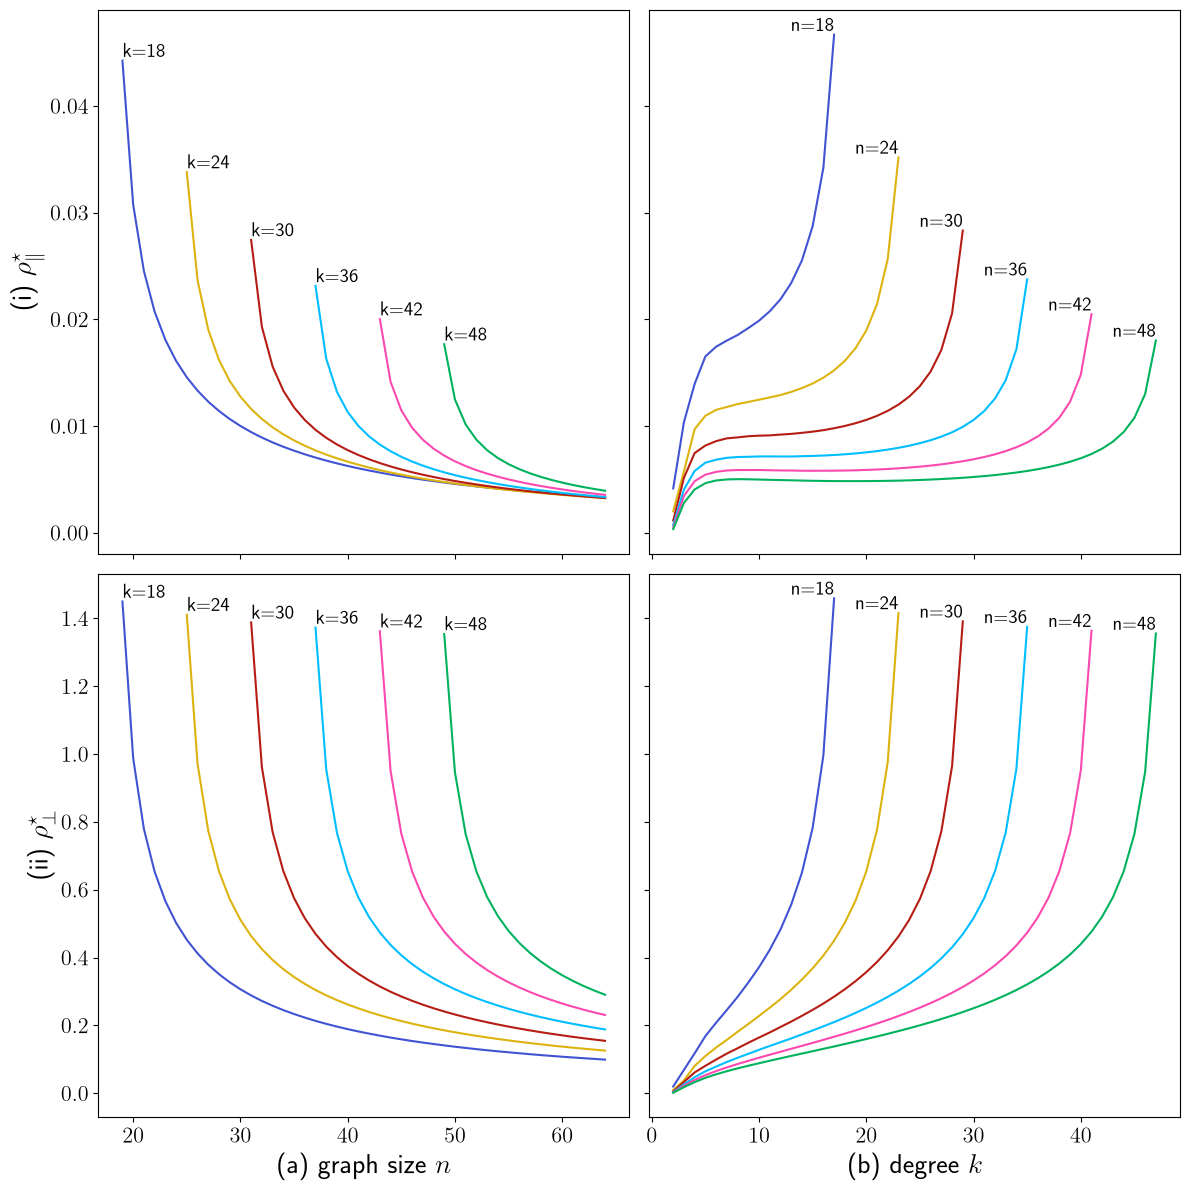

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex="col", sharey="row")

label = 18
tick_fontsize = 15

plot_curves(bounds2approx, axes[0, 0], "k", "n", "avg_rprmax", ks, "k")
plot_curves(bounds2approx, axes[0, 1], "n", "k", "avg_rprmax", ns, "n", left_label=False)
plot_curves(bounds2approx, axes[1, 0], "k", "n", "avg_rppmax", ks, "k")
plot_curves(bounds2approx, axes[1, 1], "n", "k", "avg_rppmax", ns, "n", left_label=False)

axes[0, 0].set_ylabel(r"(i) $\rho_\parallel^\star$", fontsize=label_fs)
axes[1, 0].set_ylabel(r"(ii) $\rho_\perp^\star$", fontsize=label_fs)
axes[1, 0].set_xlabel(r"(a) graph size $n$", fontsize=label_fs)
axes[1, 1].set_xlabel(r"(b) degree $k$", fontsize=label_fs)

plt.tight_layout()
plt.savefig("../images/regular-approx.png", bbox_inches="tight", dpi=400)
plt.show()

In [6]:
def plot_ratios(ax, df1, df2, col, title):
    df = df1.merge(df2, on=["n", "k"], suffixes=("_1", "_2"))
    H = df.assign(ratio=df[f"{col}_1"] / df[f"{col}_2"]).pivot(index="k", columns="n", values="ratio")
    H = H.iloc[1:, 1:]
    im = ax.pcolormesh(
        H.columns,
        H.index,
        H.values,
        shading="nearest",
        cmap="plasma",
    )

    ax.set_title(label=title, fontsize=label_fs)
    ax.set_xlabel(r"graph size $n$", fontsize=label_fs)
    ax.set_ylabel(r"degree $k$", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=13)
    cbar = plt.colorbar(im, ax=ax)

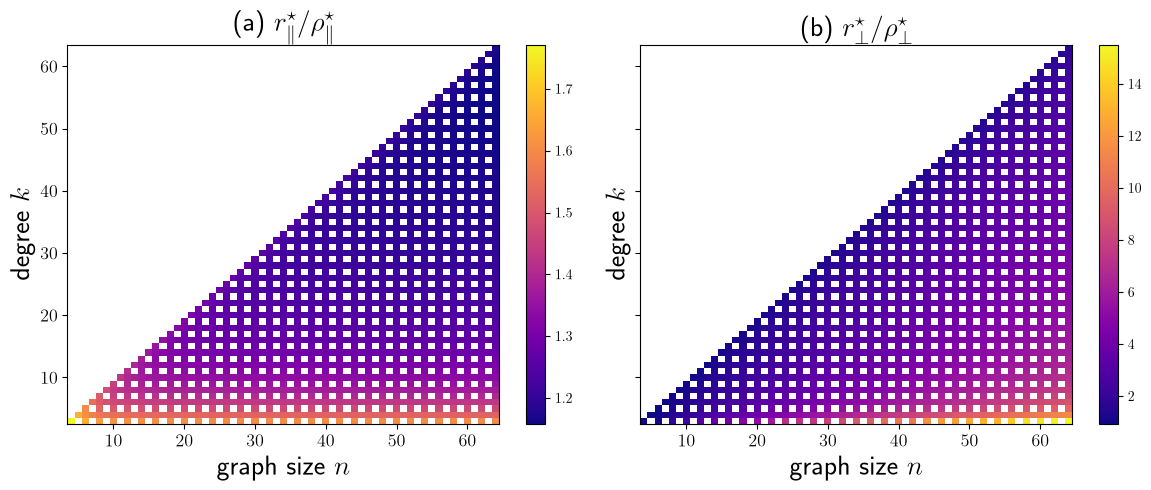

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey="row")

plot_ratios(axes[0], bounds2true, bounds2approx, "avg_rprmax", r"(a) $r_\parallel^\star / \rho_\parallel^\star$")
plot_ratios(axes[1], bounds2true, bounds2approx, "avg_rppmax", r"(b) $r_\perp^\star / \rho_\perp^\star$")

plt.tight_layout()
plt.savefig("../images/ratio-2v2.png", bbox_inches="tight", dpi=400)
plt.show()

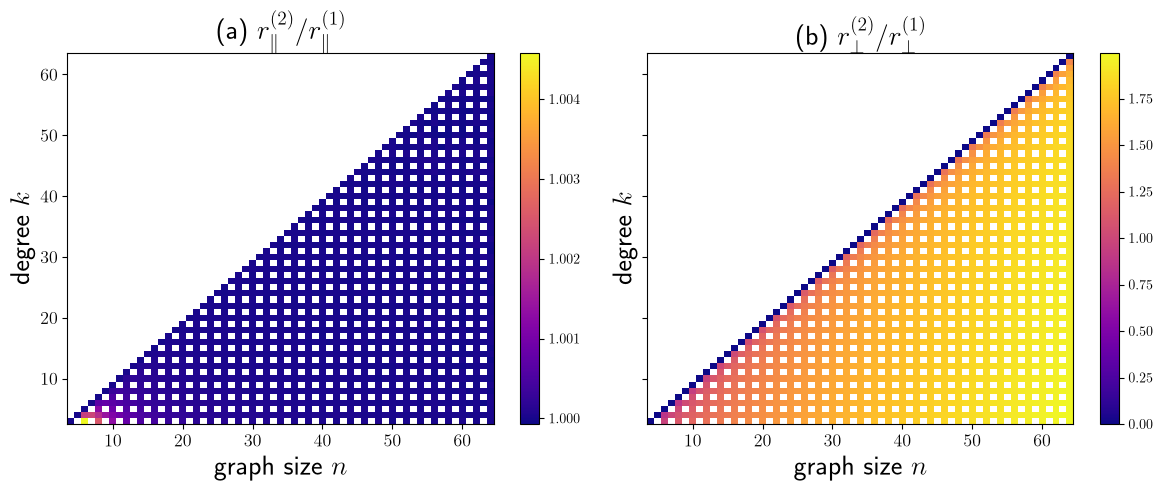

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey="row")

plot_ratios(axes[0], bounds2true, bounds1, "avg_rprmax", r"(a) $r_\parallel^{(2)} / r_\parallel^{(1)}$")
plot_ratios(axes[1], bounds2true, bounds1, "avg_rppmax", r"(b) $r_\perp^{(2)} / r_\perp^{(1)}$")

plt.tight_layout()
plt.savefig("../images/ratio-1v2.png", bbox_inches="tight", dpi=400)
plt.show()